In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import math
import torch
import torch.nn as nn

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
Using device: cuda


##  LoRA Linear Layer

We first implement the core LoRA mechanism without using PEFT or any existing LoRA implementation.

For a standard linear transformation:

$$
y = W_0x
$$

LoRA freezes \(W_0\) and introduces two trainable low-rank matrices:

$$
A \in \mathbb{R}^{r \times d_{in}}
$$

$$
B \in \mathbb{R}^{d_{out} \times r}
$$

The modified transformation is:

$$
y = W_0x + \frac{\alpha}{r}BAx
$$

Following the LoRA initialization strategy, matrix \(A\) is randomly initialized while matrix \(B\) starts at zero. Therefore, the LoRA update is initially zero.

# **1.  LoRA From Scratch**

*LoRALinear*

In [3]:
class LoRALinear(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        rank=4,
        alpha=8,
        bias=True
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank

        # Original linear layer (represents pretrained weights W0)
        self.linear = nn.Linear(
            in_features,
            out_features,
            bias=bias
        )

        # Freeze original pretrained weights
        for parameter in self.linear.parameters():
            parameter.requires_grad = False

        # LoRA matrix A: [rank, in_features]
        self.lora_A = nn.Parameter(
            torch.empty(rank, in_features)
        )

        # LoRA matrix B: [out_features, rank]
        self.lora_B = nn.Parameter(
            torch.zeros(out_features, rank)
        )

        # Initialize A randomly
        nn.init.kaiming_uniform_(
            self.lora_A,
            a=math.sqrt(5)
        )

    def forward(self, x):

        # Frozen pretrained transformation
        base_output = self.linear(x)

        # Low-rank LoRA update
        lora_output = (
            (x @ self.lora_A.T)
            @ self.lora_B.T
        )

        # W0x + (alpha/r)BAx
        return base_output + self.scaling * lora_output

In [4]:
lora_layer = LoRALinear(
    in_features=768,
    out_features=768,
    rank=8,
    alpha=16
)

x = torch.randn(2, 10, 768)

output = lora_layer(x)

print("Input shape :", x.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([2, 10, 768])
Output shape: torch.Size([2, 10, 768])


*Check frozen vs trainable parameters*

In [5]:
print("Parameter status:\n")

for name, parameter in lora_layer.named_parameters():

    status = "TRAINABLE" if parameter.requires_grad else "FROZEN"

    print(
        f"{name:20s} "
        f"shape={str(tuple(parameter.shape)):15s} "
        f"{status}"
    )

Parameter status:

lora_A               shape=(8, 768)        TRAINABLE
lora_B               shape=(768, 8)        TRAINABLE
linear.weight        shape=(768, 768)      FROZEN
linear.bias          shape=(768,)          FROZEN


# **2. Verify Parameter Efficiency**

##  Parameter Efficiency

The main advantage of LoRA is that it drastically reduces the number of parameters that must be trained.

For a standard linear layer with weight matrix

$$
W_0 \in \mathbb{R}^{d_{out} \times d_{in}}
$$

full fine-tuning updates approximately

$$
d_{out} \times d_{in}
$$

weight parameters.

LoRA instead trains two low-rank matrices:

$$
A \in \mathbb{R}^{r \times d_{in}}
$$

and

$$
B \in \mathbb{R}^{d_{out} \times r}
$$

giving

$$
r(d_{in} + d_{out})
$$

trainable parameters.

When \(r\) is much smaller than the model dimension, the number of trainable parameters is greatly reduced.

*Count parameters*

In [6]:
def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    frozen = total - trainable

    return total, trainable, frozen


total, trainable, frozen = count_parameters(lora_layer)

print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Frozen parameters    : {frozen:,}")

print(
    f"Trainable percentage : "
    f"{100 * trainable / total:.4f}%"
)

Total parameters     : 602,880
Trainable parameters : 12,288
Frozen parameters    : 590,592
Trainable percentage : 2.0382%


# **3. Verify Zero-Update Initialization**

##  Zero-Update Initialization Verification

LoRA initializes matrix \(A\) randomly and matrix \(B\) to zero.

Therefore, at initialization:

$$
BA = 0
$$

and consequently:

$$
W_0x + \frac{\alpha}{r}BAx = W_0x
$$

The LoRA-augmented layer should therefore produce exactly the same output as the frozen base layer before training begins.

In [7]:
with torch.no_grad():

    base_output = lora_layer.linear(x)

    lora_output = lora_layer(x)

    max_difference = (
        base_output - lora_output
    ).abs().max().item()


print(
    "Maximum difference between "
    "base and LoRA output:",
    max_difference
)

print(
    "Outputs identical:",
    torch.allclose(
        base_output,
        lora_output,
        atol=1e-6
    )
)

Maximum difference between base and LoRA output: 0.0
Outputs identical: True


*Verify gradients*

In [8]:
lora_layer.zero_grad()

output = lora_layer(x)

loss = output.pow(2).mean()

loss.backward()

print("Gradient check:\n")

for name, parameter in lora_layer.named_parameters():

    has_gradient = parameter.grad is not None

    print(
        f"{name:20s}",
        "gradient:",
        has_gradient
    )

Gradient check:

lora_A               gradient: True
lora_B               gradient: True
linear.weight        gradient: False
linear.bias          gradient: False


# **4. Prepare a Real Pretrained Model**

## Applying LoRA to a Pretrained Transformer

We now move from a standalone linear layer to a real pretrained Transformer model.

The goal is to:

1. Load a pretrained model.
2. Inspect its linear layers.
3. Inject our own LoRA implementation into selected modules.
4. Freeze the original pretrained weights.
5. Train only the LoRA parameters and task head.
6. Compare LoRA fine-tuning against full fine-tuning.

For this scaled reproduction, we use a compact pretrained Transformer so that the experiments can run efficiently on a single Colab GPU.

In [9]:
!pip -q install transformers datasets evaluate accelerate

In [10]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from datasets import load_dataset

import numpy as np
import pandas as pd

# **5. Load model**

In [11]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model = model.to(device)

print("Model loaded successfully")
print("Model:", model_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Model: distilbert-base-uncased


In [12]:
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        print(name, "->", module)

distilbert.transformer.layer.0.attention.q_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.0.attention.k_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.0.attention.v_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.0.attention.out_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.0.ffn.lin1 -> Linear(in_features=768, out_features=3072, bias=True)
distilbert.transformer.layer.0.ffn.lin2 -> Linear(in_features=3072, out_features=768, bias=True)
distilbert.transformer.layer.1.attention.q_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.1.attention.k_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.1.attention.v_lin -> Linear(in_features=768, out_features=768, bias=True)
distilbert.transformer.layer.1.attention.out_lin -> Linear(in_features=768, out_fea

# **6. Inject LoRA Into DistilBERT**

##  Injecting Custom LoRA Modules

We now replace selected attention projection layers inside DistilBERT with our custom `LoRALinear` module.

For this experiment, LoRA is applied to the query and value projection layers:

- `q_lin`
- `v_lin`

The original pretrained weights are copied into the frozen base linear layer, while only the low-rank matrices remain trainable.

*helper to replace a linear layer*

In [13]:
def convert_linear_to_lora(
    linear_layer,
    rank=8,
    alpha=16
):
    lora_layer = LoRALinear(
        in_features=linear_layer.in_features,
        out_features=linear_layer.out_features,
        rank=rank,
        alpha=alpha,
        bias=linear_layer.bias is not None
    )

    # Copy pretrained weights into frozen base layer
    with torch.no_grad():
        lora_layer.linear.weight.copy_(
            linear_layer.weight
        )

        if linear_layer.bias is not None:
            lora_layer.linear.bias.copy_(
                linear_layer.bias
            )

    return lora_layer

*inject LoRA into q and v projections*

In [14]:
def inject_lora_into_distilbert(
    model,
    rank=8,
    alpha=16
):
    replaced_layers = []

    for layer_index, layer in enumerate(
        model.distilbert.transformer.layer
    ):

        layer.attention.q_lin = convert_linear_to_lora(
            layer.attention.q_lin,
            rank=rank,
            alpha=alpha
        )

        replaced_layers.append(
            f"layer.{layer_index}.attention.q_lin"
        )

        layer.attention.v_lin = convert_linear_to_lora(
            layer.attention.v_lin,
            rank=rank,
            alpha=alpha
        )

        replaced_layers.append(
            f"layer.{layer_index}.attention.v_lin"
        )

    return replaced_layers

# **7. Freeze Everything Except LoRA + Classifier**

In [15]:
# Freeze every parameter first
for parameter in model.parameters():
    parameter.requires_grad = False


replaced_layers = inject_lora_into_distilbert(
    model,
    rank=8,
    alpha=16
)


# Re-enable LoRA parameters
for name, parameter in model.named_parameters():

    if "lora_A" in name or "lora_B" in name:
        parameter.requires_grad = True


# Keep the task-specific classification head trainable
for parameter in model.pre_classifier.parameters():
    parameter.requires_grad = True

for parameter in model.classifier.parameters():
    parameter.requires_grad = True


model = model.to(device)

print("LoRA injection complete")
print("Number of replaced layers:", len(replaced_layers))

print("\nFirst few replaced modules:")

for name in replaced_layers[:6]:
    print(name)

LoRA injection complete
Number of replaced layers: 12

First few replaced modules:
layer.0.attention.q_lin
layer.0.attention.v_lin
layer.1.attention.q_lin
layer.1.attention.v_lin
layer.2.attention.q_lin
layer.2.attention.v_lin


*verify parameter efficiency*

In [16]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

print(
    f"Trainable percentage : "
    f"{100 * trainable_params / total_params:.4f}%"
)

Total parameters     : 67,102,466
Trainable parameters : 739,586
Trainable percentage : 1.1022%


*verify what is trainable*

In [17]:
print("Trainable parameters:\n")

for name, parameter in model.named_parameters():

    if parameter.requires_grad:
        print(
            name,
            "->",
            tuple(parameter.shape)
        )

Trainable parameters:

distilbert.transformer.layer.0.attention.q_lin.lora_A -> (8, 768)
distilbert.transformer.layer.0.attention.q_lin.lora_B -> (768, 8)
distilbert.transformer.layer.0.attention.v_lin.lora_A -> (8, 768)
distilbert.transformer.layer.0.attention.v_lin.lora_B -> (768, 8)
distilbert.transformer.layer.1.attention.q_lin.lora_A -> (8, 768)
distilbert.transformer.layer.1.attention.q_lin.lora_B -> (768, 8)
distilbert.transformer.layer.1.attention.v_lin.lora_A -> (8, 768)
distilbert.transformer.layer.1.attention.v_lin.lora_B -> (768, 8)
distilbert.transformer.layer.2.attention.q_lin.lora_A -> (8, 768)
distilbert.transformer.layer.2.attention.q_lin.lora_B -> (768, 8)
distilbert.transformer.layer.2.attention.v_lin.lora_A -> (8, 768)
distilbert.transformer.layer.2.attention.v_lin.lora_B -> (768, 8)
distilbert.transformer.layer.3.attention.q_lin.lora_A -> (8, 768)
distilbert.transformer.layer.3.attention.q_lin.lora_B -> (768, 8)
distilbert.transformer.layer.3.attention.v_lin.lora_A

# **8. Load a Real Dataset**

##  Dataset Preparation — SST-2

We use the SST-2 sentiment classification dataset from the GLUE benchmark.

Each example contains a sentence and a binary sentiment label:

- `0` = negative
- `1` = positive

This gives us a controlled downstream task for comparing:

- LoRA fine-tuning
- Full fine-tuning
- Different LoRA ranks
- Parameter efficiency
- Training time and validation accuracy

In [18]:
!pip -q install -U datasets huggingface_hub

In [19]:
dataset = load_dataset(
    "nyu-mll/glue",
    "sst2"
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [20]:
print("Training example:")
print(dataset["train"][0])

print("\nValidation example:")
print(dataset["validation"][0])

Training example:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}

Validation example:
{'sentence': "it 's a charming and often affecting journey . ", 'label': 1, 'idx': 0}


# **9. Tokenize the Dataset**

## Tokenization

The pretrained DistilBERT tokenizer converts raw text into token IDs and attention masks.

We truncate or pad each sentence to a fixed maximum sequence length so the examples can be batched efficiently.

*Tokenization function*

In [21]:
MAX_LENGTH = 128


def tokenize_batch(batch):

    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [22]:
tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True
)

tokenized_dataset = tokenized_dataset.remove_columns(
    ["sentence", "idx"]
)

tokenized_dataset = tokenized_dataset.rename_column(
    "label",
    "labels"
)

tokenized_dataset.set_format(
    "torch"
)

print(tokenized_dataset)

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1821
    })
})


# **10. Use a Scaled Training Subset**

##  Scaled Experimental Dataset

To keep the reproduction practical on a single Colab GPU, the first experiment uses a subset of SST-2.

This is an experimental scaling decision rather than a claim of reproducing the original LoRA paper's full training setup.

The same subset will be used for all comparison runs to keep the experiments fair.

In [23]:
TRAIN_SIZE = 8000
VAL_SIZE = 1000

train_dataset = (
    tokenized_dataset["train"]
    .shuffle(seed=42)
    .select(range(TRAIN_SIZE))
)

val_dataset = (
    tokenized_dataset["validation"]
    .shuffle(seed=42)
    .select(
        range(
            min(
                VAL_SIZE,
                len(tokenized_dataset["validation"])
            )
        )
    )
)

print("Training examples  :", len(train_dataset))
print("Validation examples:", len(val_dataset))

Training examples  : 8000
Validation examples: 872


# **11. Create DataLoaders**

In [24]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches  : 250
Validation batches: 28


In [25]:
batch = next(iter(train_loader))

for key, value in batch.items():
    print(
        key,
        value.shape,
        value.dtype
    )

labels torch.Size([32]) torch.int64
input_ids torch.Size([32, 128]) torch.int64
token_type_ids torch.Size([32, 128]) torch.int64
attention_mask torch.Size([32, 128]) torch.int64


# **12. Training and Evaluation Functions**

##  Training and Evaluation

We now train the LoRA-adapted DistilBERT model on SST-2.

During training:

- the original pretrained Transformer weights remain frozen
- only LoRA parameters and the classification head are updated
- validation accuracy is measured after each epoch
- training time is recorded for later comparison with full fine-tuning

In [26]:
import time

from torch.optim import AdamW
from tqdm.auto import tqdm

*training function*

In [27]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        dataloader,
        desc="Training"
    )

    for batch in progress_bar:

        batch = {
            key: value.to(device)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    average_loss = total_loss / len(dataloader)

    return average_loss

# **13. Validation Function**

In [28]:
def evaluate_model(
    model,
    dataloader,
    device
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for batch in tqdm(
            dataloader,
            desc="Validation"
        ):

            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            loss = outputs.loss
            logits = outputs.logits

            predictions = torch.argmax(
                logits,
                dim=-1
            )

            total_loss += loss.item()

            correct += (
                predictions == batch["labels"]
            ).sum().item()

            total += batch["labels"].size(0)

    average_loss = total_loss / len(dataloader)

    accuracy = correct / total

    return average_loss, accuracy

# **14. Set Up First LoRA Experiment**

## Baseline LoRA Fine-Tuning Experiment

The baseline LoRA configuration uses:

- Rank: 8
- Alpha: 16
- Target modules: query and value projections
- Training subset: 8,000 SST-2 examples
- Batch size: 32
- Optimizer: AdamW
- Epochs: 3

The resulting validation accuracy, runtime, and trainable parameter count will later be compared against full fine-tuning and other LoRA configurations.

*Optimizer and experiment settings*

In [29]:
LEARNING_RATE = 2e-4
EPOCHS = 3

optimizer = AdamW(
    [
        p
        for p in model.parameters()
        if p.requires_grad
    ],
    lr=LEARNING_RATE
)

print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Learning rate: 0.0002
Epochs: 3


# **15. Train Baseline LoRA**

In [30]:
lora_history = []

start_time = time.time()

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        device
    )

    lora_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )


lora_training_time = time.time() - start_time

print(
    "\nTotal LoRA training time:",
    f"{lora_training_time:.2f} seconds"
)


Epoch 1/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.3768
Validation Loss: 0.3033
Validation Accuracy: 0.8693

Epoch 2/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.2805
Validation Loss: 0.3096
Validation Accuracy: 0.8693

Epoch 3/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.2480
Validation Loss: 0.2815
Validation Accuracy: 0.8853

Total LoRA training time: 180.78 seconds


In [31]:
lora_history_df = pd.DataFrame(
    lora_history
)

lora_history_df

,epoch,train_loss,val_loss,val_accuracy
0,1,0.376772,0.303306,0.869266
1,2,0.280459,0.309565,0.869266
2,3,0.247998,0.281507,0.885321


# **16. Full Fine-Tuning Baseline**

## Full Fine-Tuning Baseline

To evaluate the parameter efficiency of LoRA, we compare it against conventional full fine-tuning.

For full fine-tuning:

- the same pretrained DistilBERT checkpoint is used
- all model parameters are trainable
- the same SST-2 training and validation subsets are used
- the same number of epochs and batch size are used

We record:

- validation accuracy
- training loss
- training time
- number of trainable parameters

This allows us to study the trade-off between downstream performance and parameter efficiency.

In [32]:
full_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

full_model = full_model.to(device)

print("Fresh model loaded for full fine-tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded for full fine-tuning.


*Verify all parameters are trainable*

In [33]:
full_total_params = sum(
    p.numel()
    for p in full_model.parameters()
)

full_trainable_params = sum(
    p.numel()
    for p in full_model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters     : "
    f"{full_total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{full_trainable_params:,}"
)

print(
    f"Trainable percentage : "
    f"{100 * full_trainable_params / full_total_params:.2f}%"
)

Total parameters     : 66,955,010
Trainable parameters : 66,955,010
Trainable percentage : 100.00%


# **17. Train Full Fine-Tuning Baseline**

##Full Fine-Tuning Experiment

A lower learning rate is used for full fine-tuning because all pretrained model parameters are being updated.

The LoRA experiment uses a higher learning rate because only the low-rank adapters and classification head are optimized.

Other major experimental conditions, including the dataset subset, batch size, epoch count, and evaluation set, remain fixed.

*optimizer*

In [34]:
FULL_FT_LR = 2e-5

full_optimizer = AdamW(
    full_model.parameters(),
    lr=FULL_FT_LR
)

print(
    "Full fine-tuning learning rate:",
    FULL_FT_LR
)

Full fine-tuning learning rate: 2e-05


*Train*

In [35]:
full_history = []

start_time = time.time()

for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
    )

    train_loss = train_one_epoch(
        full_model,
        train_loader,
        full_optimizer,
        device
    )

    val_loss, val_accuracy = evaluate_model(
        full_model,
        val_loader,
        device
    )

    full_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )


full_training_time = (
    time.time() - start_time
)

print(
    "\nTotal full fine-tuning time:",
    f"{full_training_time:.2f} seconds"
)


Epoch 1/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.3612
Validation Loss: 0.2662
Validation Accuracy: 0.8784

Epoch 2/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.1788
Validation Loss: 0.2946
Validation Accuracy: 0.8784

Epoch 3/3


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.0873
Validation Loss: 0.4177
Validation Accuracy: 0.8647

Total full fine-tuning time: 249.24 seconds


# **18. Build First Real Comparison**

In [36]:
full_history_df = pd.DataFrame(
    full_history
)

full_history_df

,epoch,train_loss,val_loss,val_accuracy
0,1,0.361161,0.266234,0.878440
1,2,0.178816,0.294639,0.878440
2,3,0.087312,0.417714,0.864679


In [37]:
best_lora_accuracy = (
    lora_history_df["val_accuracy"].max()
)

best_full_accuracy = (
    full_history_df["val_accuracy"].max()
)


comparison_df = pd.DataFrame({
    "Method": [
        "LoRA",
        "Full Fine-Tuning"
    ],

    "Trainable Parameters": [
        trainable_params,
        full_trainable_params
    ],

    "Trainable %": [
        100 * trainable_params / total_params,
        100 * full_trainable_params / full_total_params
    ],

    "Best Validation Accuracy": [
        best_lora_accuracy,
        best_full_accuracy
    ],

    "Training Time (sec)": [
        lora_training_time,
        full_training_time
    ]
})

comparison_df

,Method,Trainable Parameters,Trainable %,Best Validation Accuracy,Training Time (sec)
0,LoRA,739586,1.102174,0.885321,180.776175
1,Full Fine-Tuning,66955010,100.000000,0.878440,249.243258


# **19. Rank Ablation**

## LoRA Rank Ablation

LoRA represents the weight update using two low-rank matrices.

The rank \(r\) controls the capacity of the adaptation:

- smaller rank → fewer trainable parameters
- larger rank → more expressive adaptation
- larger rank also increases training cost

We test:

- \(r = 1\)
- \(r = 2\)
- \(r = 4\)
- \(r = 8\)
- \(r = 16\)

For each rank, we record:

- trainable parameter count
- validation accuracy
- training time

*Helper to build a fresh LoRA model*

In [38]:
from transformers import set_seed


def create_lora_model(
    rank,
    alpha
):
    set_seed(42)

    fresh_model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_name,
            num_labels=2
        )
    )

    # Freeze everything first
    for parameter in fresh_model.parameters():
        parameter.requires_grad = False

    # Inject LoRA
    inject_lora_into_distilbert(
        fresh_model,
        rank=rank,
        alpha=alpha
    )

    # Enable LoRA parameters
    for name, parameter in fresh_model.named_parameters():

        if (
            "lora_A" in name
            or "lora_B" in name
        ):
            parameter.requires_grad = True

    # Classification head remains trainable
    for parameter in (
        fresh_model.pre_classifier.parameters()
    ):
        parameter.requires_grad = True

    for parameter in (
        fresh_model.classifier.parameters()
    ):
        parameter.requires_grad = True

    fresh_model = fresh_model.to(device)

    return fresh_model

# **20. Ablation Experiment Function**

In [39]:
def run_lora_experiment(
    rank,
    alpha,
    epochs=2
):

    print("\n" + "=" * 50)
    print(
        f"Running LoRA experiment: "
        f"rank={rank}, alpha={alpha}"
    )
    print("=" * 50)

    experiment_model = create_lora_model(
        rank=rank,
        alpha=alpha
    )

    experiment_trainable = sum(
        p.numel()
        for p in experiment_model.parameters()
        if p.requires_grad
    )

    experiment_total = sum(
        p.numel()
        for p in experiment_model.parameters()
    )

    optimizer = AdamW(
        [
            p
            for p in experiment_model.parameters()
            if p.requires_grad
        ],
        lr=2e-4
    )

    start_time = time.time()

    best_accuracy = 0.0

    for epoch in range(epochs):

        print(
            f"\nEpoch {epoch + 1}/{epochs}"
        )

        train_loss = train_one_epoch(
            experiment_model,
            train_loader,
            optimizer,
            device
        )

        val_loss, val_accuracy = evaluate_model(
            experiment_model,
            val_loader,
            device
        )

        best_accuracy = max(
            best_accuracy,
            val_accuracy
        )

        print(
            f"Train Loss: {train_loss:.4f}"
        )

        print(
            f"Validation Accuracy: "
            f"{val_accuracy:.4f}"
        )

    training_time = (
        time.time() - start_time
    )

    result = {
        "rank": rank,
        "alpha": alpha,
        "trainable_parameters":
            experiment_trainable,
        "trainable_percentage":
            100
            * experiment_trainable
            / experiment_total,
        "best_val_accuracy":
            best_accuracy,
        "training_time_sec":
            training_time
    }

    del experiment_model

    torch.cuda.empty_cache()

    return result

# **21. Run All Rank Experiments**

In [40]:
RANKS = [
    1,
    2,
    4,
    8,
    16
]

rank_results = []

for rank in RANKS:

    alpha = 2 * rank

    result = run_lora_experiment(
        rank=rank,
        alpha=alpha,
        epochs=2
    )

    rank_results.append(
        result
    )


Running LoRA experiment: rank=1, alpha=2


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/2


Training:   0%|          | 0/250 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.3568
Validation Accuracy: 0.8704

Epoch 2/2


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

Train Loss: 0.2703
Validation Accuracy: 0.8739


# **22. View Rank Results**

In [41]:
rank_results_df = pd.DataFrame(
    rank_results
)

rank_results_df

,rank,alpha,trainable_parameters,trainable_percentage,best_val_accuracy,training_time_sec
0,1,2,610562,0.911648,0.850917,115.802518
1,2,4,628994,0.938911,0.848624,117.165676
2,4,8,665858,0.993392,0.872706,117.414032
3,8,16,739586,1.102174,0.869266,116.945274
4,16,32,887042,1.319023,0.873853,116.904615


# **23. Plot Rank vs Accuracy**

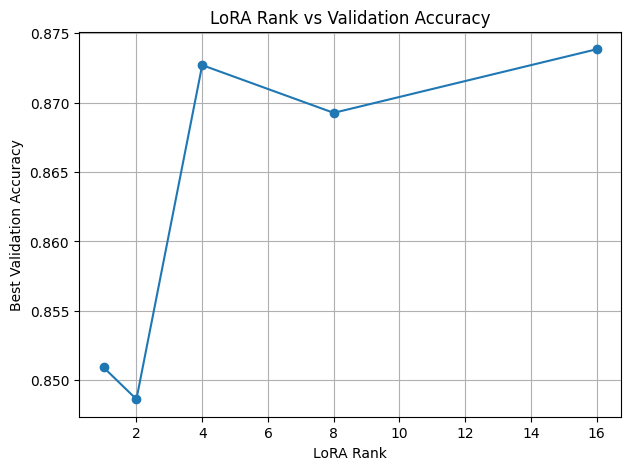

In [42]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))

plt.plot(
    rank_results_df["rank"],
    rank_results_df[
        "best_val_accuracy"
    ],
    marker="o"
)

plt.xlabel("LoRA Rank")
plt.ylabel("Best Validation Accuracy")

plt.title(
    "LoRA Rank vs Validation Accuracy"
)

plt.grid(True)

plt.show()

*Plot Rank vs Trainable Parameters*

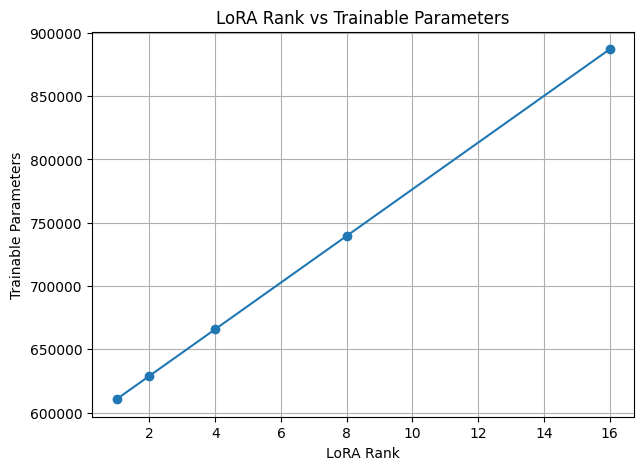

In [43]:
plt.figure(figsize=(7, 5))

plt.plot(
    rank_results_df["rank"],
    rank_results_df[
        "trainable_parameters"
    ],
    marker="o"
)

plt.xlabel("LoRA Rank")
plt.ylabel("Trainable Parameters")

plt.title(
    "LoRA Rank vs Trainable Parameters"
)

plt.grid(True)

plt.show()

# **24. Separate Adapter vs Classification-Head Parameters**

## Detailed Trainable Parameter Analysis

Our downstream classification experiment trains two types of parameters:

1. **LoRA adapter parameters** — the low-rank matrices \(A\) and \(B\)
2. **Task-head parameters** — the DistilBERT classification head

These are reported separately so that the parameter efficiency of the LoRA adaptation itself is not confused with the parameters required by the downstream classification task.

In [44]:
def parameter_breakdown(model):

    lora_params = 0
    classifier_params = 0
    frozen_params = 0

    for name, parameter in model.named_parameters():

        if "lora_A" in name or "lora_B" in name:
            lora_params += parameter.numel()

        elif (
            name.startswith("pre_classifier")
            or name.startswith("classifier")
        ):
            classifier_params += parameter.numel()

        elif not parameter.requires_grad:
            frozen_params += parameter.numel()

    return {
        "LoRA Adapter Parameters": lora_params,
        "Classification Head Parameters": classifier_params,
        "Total Trainable Parameters":
            lora_params + classifier_params,
        "Frozen Parameters": frozen_params
    }


breakdown = parameter_breakdown(model)

for name, value in breakdown.items():
    print(f"{name:35s}: {value:,}")

LoRA Adapter Parameters            : 147,456
Classification Head Parameters     : 592,130
Total Trainable Parameters         : 739,586
Frozen Parameters                  : 66,362,880


# **25. Calculate Parameter Reduction**

In [45]:
lora_adapter_params = breakdown[
    "LoRA Adapter Parameters"
]

parameter_reduction = (
    1
    - (
        lora_adapter_params
        / full_trainable_params
    )
) * 100


print(
    f"Full fine-tuning trainable parameters: "
    f"{full_trainable_params:,}"
)

print(
    f"LoRA adapter parameters: "
    f"{lora_adapter_params:,}"
)

print(
    f"Parameter reduction: "
    f"{parameter_reduction:.4f}%"
)

Full fine-tuning trainable parameters: 66,955,010
LoRA adapter parameters: 147,456
Parameter reduction: 99.7798%


# **26. Why Adapter-Only Saving Matters**

## Adapter-Only Checkpointing

One practical advantage of LoRA is that we do not need to store a complete copy of the fine-tuned language model for every downstream task.

The pretrained base model remains unchanged while the learned low-rank matrices can be stored separately.

We therefore implement adapter-only checkpointing containing:

- LoRA matrix \(A\)
- LoRA matrix \(B\)
- classification-head parameters

This demonstrates how parameter-efficient fine-tuning can also reduce task-specific checkpoint storage.

In [46]:
def get_adapter_state_dict(model):

    adapter_state = {}

    for name, parameter in model.state_dict().items():

        if (
            "lora_A" in name
            or "lora_B" in name
            or name.startswith("pre_classifier")
            or name.startswith("classifier")
        ):

            adapter_state[name] = (
                parameter.detach().cpu()
            )

    return adapter_state

In [47]:
adapter_state = get_adapter_state_dict(
    model
)

print(
    "Number of tensors saved:",
    len(adapter_state)
)

print("\nFirst few tensors:")

for name in list(adapter_state.keys())[:10]:
    print(
        name,
        adapter_state[name].shape
    )

Number of tensors saved: 28

First few tensors:
distilbert.transformer.layer.0.attention.q_lin.lora_A torch.Size([8, 768])
distilbert.transformer.layer.0.attention.q_lin.lora_B torch.Size([768, 8])
distilbert.transformer.layer.0.attention.v_lin.lora_A torch.Size([8, 768])
distilbert.transformer.layer.0.attention.v_lin.lora_B torch.Size([768, 8])
distilbert.transformer.layer.1.attention.q_lin.lora_A torch.Size([8, 768])
distilbert.transformer.layer.1.attention.q_lin.lora_B torch.Size([768, 8])
distilbert.transformer.layer.1.attention.v_lin.lora_A torch.Size([8, 768])
distilbert.transformer.layer.1.attention.v_lin.lora_B torch.Size([768, 8])
distilbert.transformer.layer.2.attention.q_lin.lora_A torch.Size([8, 768])
distilbert.transformer.layer.2.attention.q_lin.lora_B torch.Size([768, 8])


# **27. Save the LoRA Adapter Checkpoint**

In [48]:
import os

adapter_path = "lora_adapter_sst2.pt"

torch.save(
    adapter_state,
    adapter_path
)

print(
    "Adapter checkpoint saved:",
    adapter_path
)

Adapter checkpoint saved: lora_adapter_sst2.pt


## **28. Compare Adapter Size vs Full Model Size**

In [49]:
full_model_path = "full_finetuned_model.pt"

torch.save(
    full_model.state_dict(),
    full_model_path
)


adapter_size_mb = (
    os.path.getsize(adapter_path)
    / (1024 ** 2)
)

full_model_size_mb = (
    os.path.getsize(full_model_path)
    / (1024 ** 2)
)


print(
    f"Adapter checkpoint size : "
    f"{adapter_size_mb:.2f} MB"
)

print(
    f"Full model checkpoint   : "
    f"{full_model_size_mb:.2f} MB"
)

print(
    f"Storage reduction       : "
    f"{100 * (1 - adapter_size_mb / full_model_size_mb):.2f}%"
)

Adapter checkpoint size : 2.83 MB
Full model checkpoint   : 255.45 MB
Storage reduction       : 98.89%


# **29. Reload Adapter Into a Fresh Model**

##Reloading LoRA Adapters

A useful adapter checkpoint must be loadable into a fresh copy of the pretrained model.

We therefore:

1. load a new DistilBERT model
2. inject the same LoRA architecture
3. load only the saved adapter and classification-head parameters
4. verify that the reconstructed model produces the same predictions as the trained LoRA model

In [50]:
def load_lora_model_from_adapter(
    adapter_path,
    rank=8,
    alpha=16
):

    fresh_model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            model_name,
            num_labels=2
        )
    )

    # Freeze base model
    for parameter in fresh_model.parameters():
        parameter.requires_grad = False

    # Inject LoRA structure
    inject_lora_into_distilbert(
        fresh_model,
        rank=rank,
        alpha=alpha
    )

    # Load saved adapter tensors
    adapter_state = torch.load(
        adapter_path,
        map_location="cpu"
    )

    fresh_model.load_state_dict(
        adapter_state,
        strict=False
    )

    fresh_model = fresh_model.to(device)

    return fresh_model

# **30. Create Reloaded Model**

In [51]:
reloaded_model = load_lora_model_from_adapter(
    adapter_path,
    rank=8,
    alpha=16
)

reloaded_model.eval()

print(
    "LoRA adapter reloaded successfully."
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA adapter reloaded successfully.


# **31. Verify Reloaded Predictions**

In [52]:
sample_batch = next(
    iter(val_loader)
)

sample_batch = {
    key: value.to(device)
    for key, value in sample_batch.items()
}


model.eval()
reloaded_model.eval()


with torch.no_grad():

    original_logits = model(
        input_ids=sample_batch["input_ids"],
        attention_mask=sample_batch[
            "attention_mask"
        ]
    ).logits

    reloaded_logits = reloaded_model(
        input_ids=sample_batch["input_ids"],
        attention_mask=sample_batch[
            "attention_mask"
        ]
    ).logits


max_difference = (
    original_logits
    - reloaded_logits
).abs().max().item()


print(
    "Maximum logit difference:",
    max_difference
)

print(
    "Outputs match:",
    torch.allclose(
        original_logits,
        reloaded_logits,
        atol=1e-5
    )
)

Maximum logit difference: 0.0
Outputs match: True


*Clean Up the Full Checkpoint*

In [53]:
if os.path.exists(full_model_path):
    os.remove(full_model_path)

print(
    "Temporary full-model checkpoint removed."
)

Temporary full-model checkpoint removed.


# **32. LoRA Weight Merging**

## LoRA Weight Merging

LoRA computes the adapted weight as:

$$
W = W_0 + \frac{\alpha}{r}BA
$$

During deployment, the learned low-rank update can be merged directly into the frozen base weight.

This removes the need to compute the LoRA branch separately during inference.

*merge function*

In [54]:
def merge_lora_layer(lora_layer):

    if not isinstance(lora_layer, LoRALinear):
        raise TypeError("Expected a LoRALinear layer.")

    merged_layer = nn.Linear(
        lora_layer.in_features,
        lora_layer.out_features,
        bias=lora_layer.linear.bias is not None
    )

    with torch.no_grad():

        delta_weight = (
            lora_layer.scaling
            * (lora_layer.lora_B @ lora_layer.lora_A)
        )

        merged_layer.weight.copy_(
            lora_layer.linear.weight + delta_weight
        )

        if lora_layer.linear.bias is not None:
            merged_layer.bias.copy_(
                lora_layer.linear.bias
            )

    return merged_layer

*Verify merging on one LoRA layer*

In [55]:
test_lora_layer = LoRALinear(
    in_features=64,
    out_features=64,
    rank=4,
    alpha=8
).to(device)

with torch.no_grad():
    test_lora_layer.lora_B.normal_(
        mean=0.0,
        std=0.02
    )

test_input = torch.randn(
    4,
    10,
    64,
    device=device
)

test_lora_layer.eval()

with torch.no_grad():
    unmerged_output = test_lora_layer(
        test_input
    )

merged_test_layer = merge_lora_layer(
    test_lora_layer
).to(device)

merged_test_layer.eval()

with torch.no_grad():
    merged_output = merged_test_layer(
        test_input
    )

difference = (
    unmerged_output - merged_output
).abs().max().item()

print("Maximum difference:", difference)

print(
    "Outputs match:",
    torch.allclose(
        unmerged_output,
        merged_output,
        atol=1e-5
    )
)

Maximum difference: 3.725290298461914e-07
Outputs match: True


*Add full-model merge function*

In [56]:
import copy


def merge_distilbert_lora(model):

    merged_model = copy.deepcopy(model)

    for layer in merged_model.distilbert.transformer.layer:

        if isinstance(
            layer.attention.q_lin,
            LoRALinear
        ):
            layer.attention.q_lin = merge_lora_layer(
                layer.attention.q_lin
            )

        if isinstance(
            layer.attention.v_lin,
            LoRALinear
        ):
            layer.attention.v_lin = merge_lora_layer(
                layer.attention.v_lin
            )

    return merged_model.to(device)

*Merge our trained model*

In [57]:
merged_model = merge_distilbert_lora(
    model
)

merged_model.eval()

print("LoRA weights merged successfully.")

LoRA weights merged successfully.


*Check that LoRA layers disappeared*

In [58]:
remaining_lora_layers = [
    name
    for name, module in merged_model.named_modules()
    if isinstance(module, LoRALinear)
]

print(
    "Remaining LoRA layers:",
    len(remaining_lora_layers)
)

Remaining LoRA layers: 0


*Verify full-model outputs*

In [59]:
sample_batch = next(
    iter(val_loader)
)

sample_batch = {
    key: value.to(device)
    for key, value in sample_batch.items()
}

model.eval()
merged_model.eval()

with torch.no_grad():

    lora_logits = model(
        input_ids=sample_batch["input_ids"],
        attention_mask=sample_batch["attention_mask"]
    ).logits

    merged_logits = merged_model(
        input_ids=sample_batch["input_ids"],
        attention_mask=sample_batch["attention_mask"]
    ).logits

max_difference = (
    lora_logits - merged_logits
).abs().max().item()

print(
    "Maximum logit difference:",
    max_difference
)

print(
    "Merged outputs match:",
    torch.allclose(
        lora_logits,
        merged_logits,
        atol=1e-5
    )
)

Maximum logit difference: 2.384185791015625e-06
Merged outputs match: True


# **33. Benchmark LoRA vs Merged Inference**

## Inference Benchmark

LoRA introduces an additional low-rank computation during inference:

$$
W_0x + \frac{\alpha}{r}BAx
$$

After merging, inference uses:

$$
W_{\text{merged}}x
$$

We benchmark the unmerged LoRA model and the merged model using the same input batch.

The goal is to measure whether weight merging removes the additional adapter computation while preserving model predictions.

*Inference benchmark function*

In [60]:
def benchmark_inference(
    model,
    input_ids,
    attention_mask,
    warmup_runs=10,
    measured_runs=50
):
    model.eval()

    # Warm-up GPU
    with torch.no_grad():
        for _ in range(warmup_runs):
            _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.no_grad():
        for _ in range(measured_runs):
            _ = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    average_latency_ms = (
        (end_time - start_time)
        / measured_runs
        * 1000
    )

    return average_latency_ms

*Prepare benchmark input*

In [61]:
benchmark_batch = next(
    iter(val_loader)
)

benchmark_input_ids = (
    benchmark_batch["input_ids"]
    .to(device)
)

benchmark_attention_mask = (
    benchmark_batch["attention_mask"]
    .to(device)
)

print(
    "Benchmark batch size:",
    benchmark_input_ids.shape[0]
)

print(
    "Sequence length:",
    benchmark_input_ids.shape[1]
)

Benchmark batch size: 32
Sequence length: 128


*Benchmark unmerged LoRA*

In [62]:
lora_latency = benchmark_inference(
    model,
    benchmark_input_ids,
    benchmark_attention_mask
)

print(
    f"Unmerged LoRA latency: "
    f"{lora_latency:.3f} ms/batch"
)

Unmerged LoRA latency: 103.915 ms/batch


*Benchmark merged model*

In [63]:
merged_latency = benchmark_inference(
    merged_model,
    benchmark_input_ids,
    benchmark_attention_mask
)

print(
    f"Merged model latency: "
    f"{merged_latency:.3f} ms/batch"
)

Merged model latency: 100.453 ms/batch


*Compare inference latency*

In [64]:
latency_improvement = (
    (lora_latency - merged_latency)
    / lora_latency
    * 100
)

print(
    f"Unmerged LoRA : "
    f"{lora_latency:.3f} ms/batch"
)

print(
    f"Merged model  : "
    f"{merged_latency:.3f} ms/batch"
)

print(
    f"Latency change: "
    f"{latency_improvement:.2f}%"
)

Unmerged LoRA : 103.915 ms/batch
Merged model  : 100.453 ms/batch
Latency change: 3.33%


# **34. Compare Model Predictions After Merging**

*prediction function*

In [65]:
def get_predictions(
    model,
    dataloader,
    device
):
    model.eval()

    predictions = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = (
                batch["input_ids"]
                .to(device)
            )

            attention_mask = (
                batch["attention_mask"]
                .to(device)
            )

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            batch_predictions = (
                outputs.logits.argmax(dim=-1)
            )

            predictions.extend(
                batch_predictions.cpu().tolist()
            )

    return predictions

*Compare all validation predictions*

In [66]:
lora_predictions = get_predictions(
    model,
    val_loader,
    device
)

merged_predictions = get_predictions(
    merged_model,
    val_loader,
    device
)

matching_predictions = sum(
    a == b
    for a, b in zip(
        lora_predictions,
        merged_predictions
    )
)

total_predictions = len(
    lora_predictions
)

match_percentage = (
    matching_predictions
    / total_predictions
    * 100
)

print(
    "Validation examples:",
    total_predictions
)

print(
    "Matching predictions:",
    matching_predictions
)

print(
    f"Prediction agreement: "
    f"{match_percentage:.2f}%"
)

Validation examples: 872
Matching predictions: 872
Prediction agreement: 100.00%


# **35. Final Experiment Comparison Table**


We now combine the major results from the experiments into one table.

The comparison includes:

- trainable parameters
- trainable percentage
- best validation accuracy
- training time
- checkpoint size
- inference latency

This provides a compact summary of the trade-offs between full fine-tuning and LoRA.

In [67]:
final_comparison_df = pd.DataFrame({
    "Method": [
        "LoRA",
        "Full Fine-Tuning"
    ],

    "Trainable Parameters": [
        trainable_params,
        full_trainable_params
    ],

    "Trainable Percentage": [
        100 * trainable_params / total_params,
        100 * full_trainable_params / full_total_params
    ],

    "Best Validation Accuracy": [
        best_lora_accuracy,
        best_full_accuracy
    ],

    "Training Time (sec)": [
        lora_training_time,
        full_training_time
    ],

    "Checkpoint Size (MB)": [
        adapter_size_mb,
        full_model_size_mb
    ],

    "Inference Latency (ms/batch)": [
        lora_latency,
        None
    ]
})

final_comparison_df

,Method,Trainable Parameters,Trainable Percentage,Best Validation Accuracy,Training Time (sec),Checkpoint Size (MB),Inference Latency (ms/batch)
0,LoRA,739586,1.102174,0.885321,180.776175,2.830905,103.915087
1,Full Fine-Tuning,66955010,100.000000,0.878440,249.243258,255.454412,NaN


# **36. Benchmark Full Fine-Tuning Inference**

*Measure full-model inference latency*

In [68]:
full_ft_latency = benchmark_inference(
    full_model,
    benchmark_input_ids,
    benchmark_attention_mask
)

print(
    f"Full fine-tuning latency: "
    f"{full_ft_latency:.3f} ms/batch"
)

Full fine-tuning latency: 104.317 ms/batch


In [69]:
final_comparison_df.loc[
    final_comparison_df["Method"] == "Full Fine-Tuning",
    "Inference Latency (ms/batch)"
] = full_ft_latency


final_comparison_df

,Method,Trainable Parameters,Trainable Percentage,Best Validation Accuracy,Training Time (sec),Checkpoint Size (MB),Inference Latency (ms/batch)
0,LoRA,739586,1.102174,0.885321,180.776175,2.830905,103.915087
1,Full Fine-Tuning,66955010,100.000000,0.878440,249.243258,255.454412,104.317394


# **37. Add Merged LoRA Result**

In [70]:
merged_row = pd.DataFrame({
    "Method": [
        "Merged LoRA"
    ],

    "Trainable Parameters": [
        trainable_params
    ],

    "Trainable Percentage": [
        100 * trainable_params / total_params
    ],

    "Best Validation Accuracy": [
        best_lora_accuracy
    ],

    "Training Time (sec)": [
        lora_training_time
    ],

    "Checkpoint Size (MB)": [
        adapter_size_mb
    ],

    "Inference Latency (ms/batch)": [
        merged_latency
    ]
})


final_comparison_df = pd.concat(
    [
        final_comparison_df,
        merged_row
    ],
    ignore_index=True
)

final_comparison_df

,Method,Trainable Parameters,Trainable Percentage,Best Validation Accuracy,Training Time (sec),Checkpoint Size (MB),Inference Latency (ms/batch)
0,LoRA,739586,1.102174,0.885321,180.776175,2.830905,103.915087
1,Full Fine-Tuning,66955010,100.000000,0.878440,249.243258,255.454412,104.317394
2,Merged LoRA,739586,1.102174,0.885321,180.776175,2.830905,100.452617


*Plot Accuracy Comparison*  - Plot validation accuracy

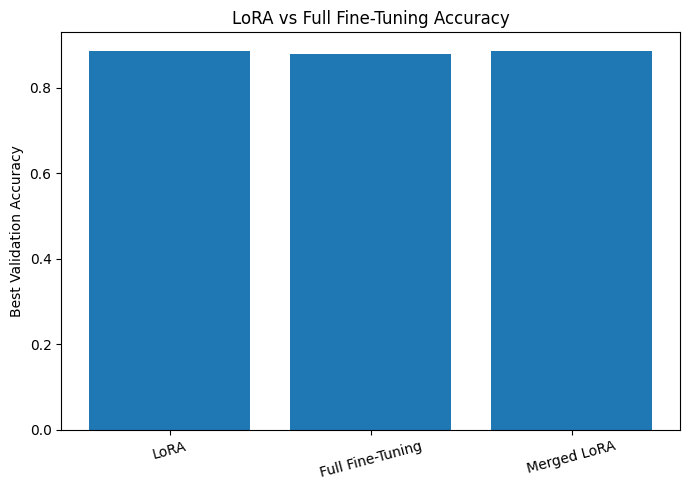

In [71]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Best Validation Accuracy"
    ]
)

plt.ylabel(
    "Best Validation Accuracy"
)

plt.title(
    "LoRA vs Full Fine-Tuning Accuracy"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

*Plot Trainable Parameters* -  Compare trainable parameter counts

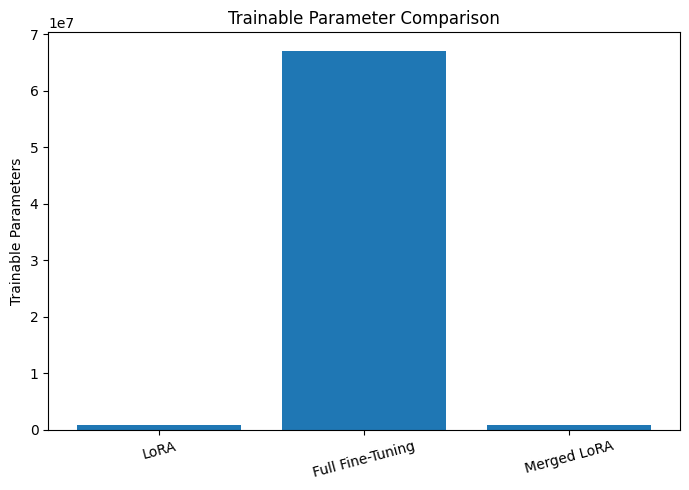

In [72]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Trainable Parameters"
    ]
)

plt.ylabel(
    "Trainable Parameters"
)

plt.title(
    "Trainable Parameter Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

*Plot Checkpoint Size*  - Compare storage requirements

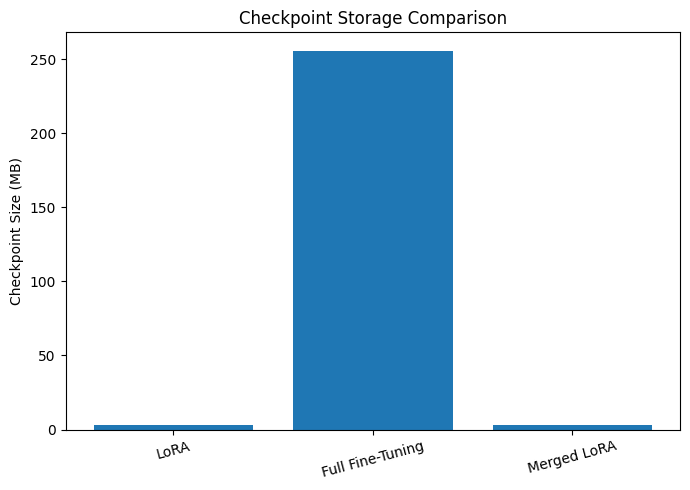

In [73]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Checkpoint Size (MB)"
    ]
)

plt.ylabel(
    "Checkpoint Size (MB)"
)

plt.title(
    "Checkpoint Storage Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

*Plot Inference Latency*  - Compare inference latency

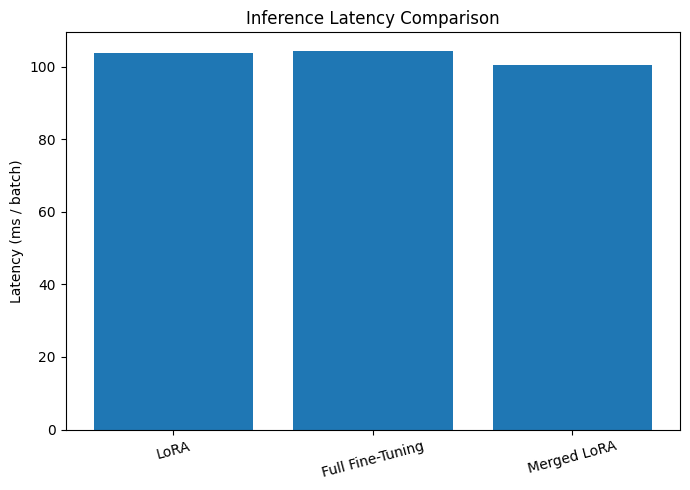

In [74]:
plt.figure(
    figsize=(7, 5)
)

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Inference Latency (ms/batch)"
    ]
)

plt.ylabel(
    "Latency (ms / batch)"
)

plt.title(
    "Inference Latency Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

# **38. Save Experimental Results**

In [75]:
import os

os.makedirs(
    "experiments",
    exist_ok=True
)

os.makedirs(
    "results",
    exist_ok=True
)

os.makedirs(
    "results/figures",
    exist_ok=True
)

print(
    "Experiment folders created."
)

Experiment folders created.


In [76]:
final_comparison_df.to_csv(
    "experiments/"
    "lora_vs_full_finetuning.csv",
    index=False
)

print(
    "Saved:"
)

print(
    "experiments/"
    "lora_vs_full_finetuning.csv"
)

Saved:
experiments/lora_vs_full_finetuning.csv


In [77]:
rank_results_df.to_csv(
    "experiments/"
    "rank_ablation_results.csv",
    index=False
)

print(
    "Saved:"
)

print(
    "experiments/"
    "rank_ablation_results.csv"
)

Saved:
experiments/rank_ablation_results.csv


In [78]:
print(
    os.listdir(
        "experiments"
    )
)

['lora_vs_full_finetuning.csv', 'rank_ablation_results.csv']


# **39. Save Experiment Figures**

*LoRA rank vs accuracy*

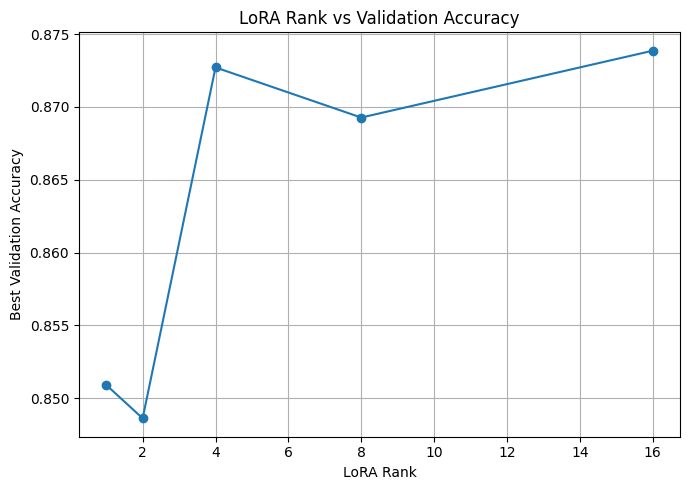

Saved: results/figures/rank_vs_accuracy.png


In [79]:
plt.figure(figsize=(7, 5))

plt.plot(
    rank_results_df["rank"],
    rank_results_df["best_val_accuracy"],
    marker="o"
)

plt.xlabel("LoRA Rank")
plt.ylabel("Best Validation Accuracy")

plt.title(
    "LoRA Rank vs Validation Accuracy"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/"
    "rank_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: results/figures/"
    "rank_vs_accuracy.png"
)

*rank vs trainable parameters*

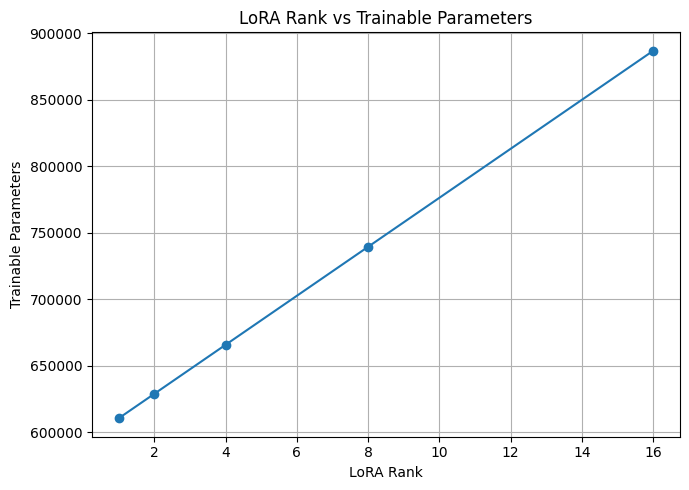

Saved: results/figures/rank_vs_parameters.png


In [80]:
plt.figure(figsize=(7, 5))

plt.plot(
    rank_results_df["rank"],
    rank_results_df[
        "trainable_parameters"
    ],
    marker="o"
)

plt.xlabel("LoRA Rank")
plt.ylabel("Trainable Parameters")

plt.title(
    "LoRA Rank vs Trainable Parameters"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/figures/"
    "rank_vs_parameters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: results/figures/"
    "rank_vs_parameters.png"
)

# **40. Save LoRA vs Full Fine-Tuning Figures**

*accuracy comparison*

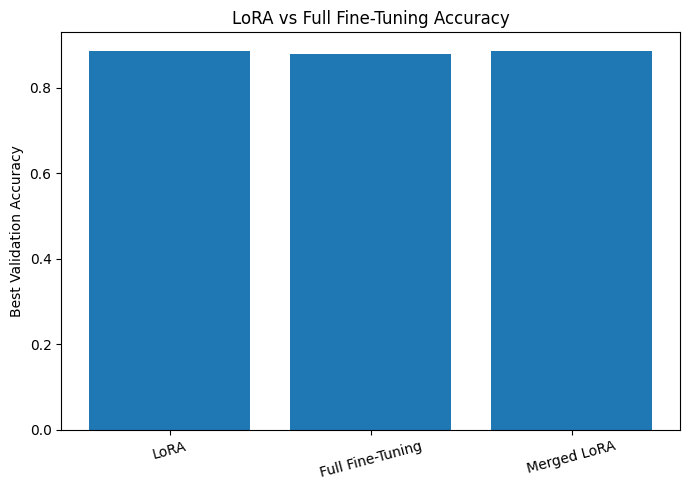

In [81]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Best Validation Accuracy"
    ]
)

plt.ylabel("Best Validation Accuracy")

plt.title(
    "LoRA vs Full Fine-Tuning Accuracy"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*trainable-parameter comparison*

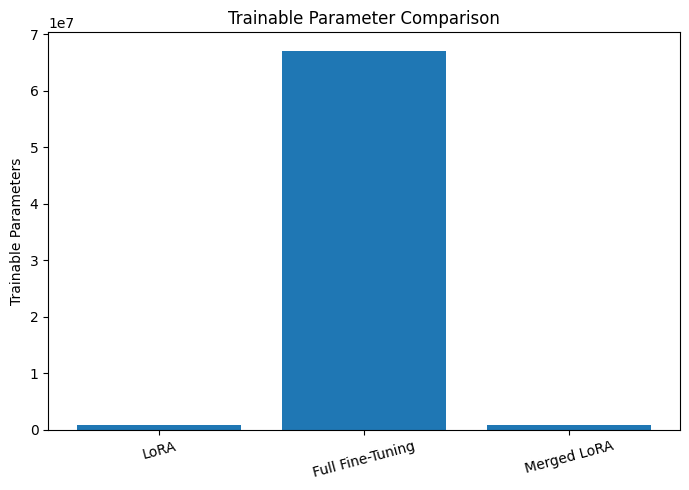

In [82]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Trainable Parameters"
    ]
)

plt.ylabel("Trainable Parameters")

plt.title(
    "Trainable Parameter Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*checkpoint-size comparison*

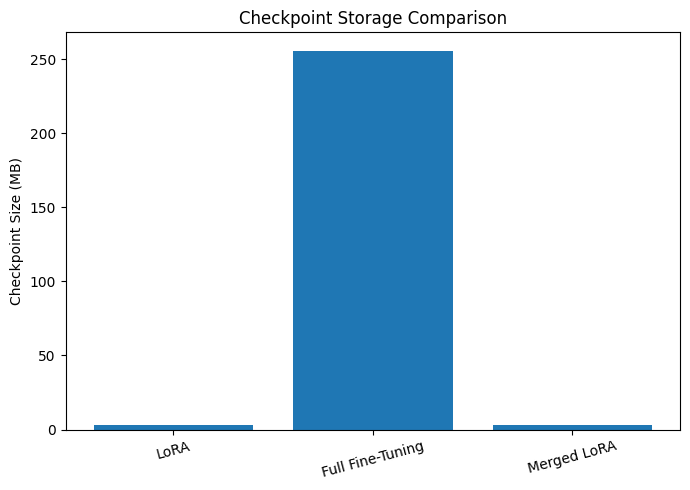

In [83]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Checkpoint Size (MB)"
    ]
)

plt.ylabel("Checkpoint Size (MB)")

plt.title(
    "Checkpoint Storage Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "checkpoint_size_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*inference-latency comparison*

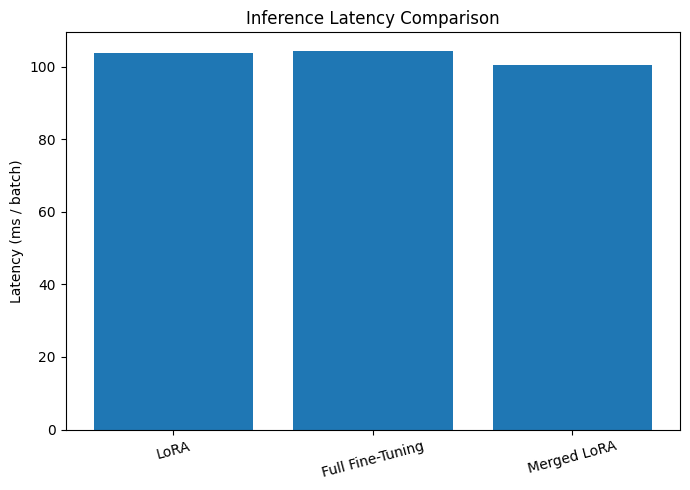

In [84]:
plt.figure(figsize=(7, 5))

plt.bar(
    final_comparison_df["Method"],
    final_comparison_df[
        "Inference Latency (ms/batch)"
    ]
)

plt.ylabel("Latency (ms / batch)")

plt.title(
    "Inference Latency Comparison"
)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "results/figures/"
    "inference_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

*verify all saved*

In [85]:
figure_files = sorted(
    os.listdir(
        "results/figures"
    )
)

print(
    "Saved figures:",
    len(figure_files)
)

for filename in figure_files:
    print(filename)

Saved figures: 6
accuracy_comparison.png
checkpoint_size_comparison.png
inference_latency_comparison.png
parameter_comparison.png
rank_vs_accuracy.png
rank_vs_parameters.png


# **40. Experiment Summary**



This section summarizes the main findings from the scaled LoRA reproduction.

The experiments compare:

- LoRA vs full fine-tuning
- different LoRA ranks
- trainable parameter counts
- validation accuracy
- checkpoint storage
- training time
- inference latency
- merged vs unmerged LoRA inference

All reported values below come from the experiments performed in this notebook.

In [86]:
best_rank_row = rank_results_df.loc[
    rank_results_df[
        "best_val_accuracy"
    ].idxmax()
]

experiment_summary = pd.DataFrame({
    "Metric": [
        "Best LoRA Validation Accuracy",
        "Best Full FT Validation Accuracy",
        "LoRA Trainable Parameters",
        "Full FT Trainable Parameters",
        "LoRA Adapter Parameters Only",
        "Parameter Reduction (%)",
        "LoRA Training Time (sec)",
        "Full FT Training Time (sec)",
        "LoRA Adapter Size (MB)",
        "Full Model Size (MB)",
        "Storage Reduction (%)",
        "Unmerged LoRA Latency (ms/batch)",
        "Merged LoRA Latency (ms/batch)",
        "Best Rank From Ablation"
    ],

    "Value": [
        best_lora_accuracy,
        best_full_accuracy,
        trainable_params,
        full_trainable_params,
        lora_adapter_params,
        parameter_reduction,
        lora_training_time,
        full_training_time,
        adapter_size_mb,
        full_model_size_mb,
        100 * (
            1
            - adapter_size_mb
            / full_model_size_mb
        ),
        lora_latency,
        merged_latency,
        int(best_rank_row["rank"])
    ]
})

experiment_summary

,Metric,Value
0,Best LoRA Validation Accuracy,8.853211e-01
1,Best Full FT Validation Accuracy,8.784404e-01
2,LoRA Trainable Parameters,7.395860e+05
3,Full FT Trainable Parameters,6.695501e+07
4,LoRA Adapter Parameters Only,1.474560e+05
5,Parameter Reduction (%),9.977977e+01
6,LoRA Training Time (sec),1.807762e+02
7,Full FT Training Time (sec),2.492433e+02
8,LoRA Adapter Size (MB),2.830905e+00
9,Full Model Size (MB),2.554544e+02


In [87]:
experiment_summary.to_csv(
    "experiments/"
    "experiment_summary.csv",
    index=False
)

print(
    "Saved: experiments/"
    "experiment_summary.csv"
)

Saved: experiments/experiment_summary.csv


In [88]:
print("Experiment files:\n")

for filename in sorted(
    os.listdir("experiments")
):
    print(filename)

Experiment files:

experiment_summary.csv
lora_vs_full_finetuning.csv
rank_ablation_results.csv


## Reproducibility

The notebook contains the complete experimental workflow used for this scaled LoRA reproduction, including:

- custom LoRA implementation
- DistilBERT integration
- SST-2 fine-tuning
- full fine-tuning baseline
- rank ablations
- adapter checkpointing
- weight merging
- inference benchmarking

In [89]:
checks = {
    "LoRA model exists":
        model is not None,

    "Merged model exists":
        merged_model is not None,

    "Full FT model exists":
        full_model is not None,

    "Rank results exist":
        len(rank_results_df) > 0,

    "Final comparison exists":
        len(final_comparison_df) > 0,

    "Experiment summary exists":
        os.path.exists(
            "experiments/"
            "experiment_summary.csv"
        ),

    "Adapter checkpoint exists":
        os.path.exists(
            "lora_adapter_sst2.pt"
        ),

    "Figures exist":
        len(
            os.listdir(
                "results/figures"
            )
        ) >= 6
}


for name, passed in checks.items():

    status = (
        "PASS"
        if passed
        else "FAIL"
    )

    print(
        f"{status:5s} - {name}"
    )

PASS  - LoRA model exists
PASS  - Merged model exists
PASS  - Full FT model exists
PASS  - Rank results exist
PASS  - Final comparison exists
PASS  - Experiment summary exists
PASS  - Adapter checkpoint exists
PASS  - Figures exist


In [90]:
import shutil

shutil.make_archive(
    "/content/lora_outputs",
    "zip",
    "/content",
    "experiments"
)

print("Experiments zipped.")

Experiments zipped.


In [91]:
shutil.make_archive(
    "/content/lora_figures",
    "zip",
    "/content/results",
    "figures"
)

print("Figures zipped.")

Figures zipped.


In [92]:
from google.colab import files

files.download(
    "/content/lora_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [93]:
files.download(
    "/content/lora_figures.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>